<a href="https://colab.research.google.com/github/Rio-HEPLab/ML4Physics/blob/PPGF-2025-1/19-VAEwithConstraint_D%C3%ADgitos_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VAE with Constraint

In [1]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from joblib import dump, load

import sklearn
import tensorflow as tf
from tensorflow import keras

print ( "sklearn: {}".format(sklearn.__version__) )
print ( "tensorflow: {}".format(tf.__version__) )

gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
if gpus:
    tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
print ( gpus )

sklearn: 1.6.1
tensorflow: 2.18.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
def sort_by_target(mnist):
    reorder_train = np.array(sorted([(target, i) for i, target in enumerate(mnist.target[:50000])]))[:, 1]
    reorder_valid = np.array(sorted([(target, i) for i, target in enumerate(mnist.target[50000:60000])]))[:, 1]
    reorder_test = np.array(sorted([(target, i) for i, target in enumerate(mnist.target[60000:])]))[:, 1]
    mnist.data[:50000] = mnist.data[reorder_train]
    mnist.target[:50000] = mnist.target[reorder_train]
    mnist.data[50000:60000] = mnist.data[reorder_valid + 50000]
    mnist.target[50000:60000] = mnist.target[reorder_valid + 50000]
    mnist.data[60000:] = mnist.data[reorder_test + 60000]
    mnist.target[60000:] = mnist.target[reorder_test + 60000]

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
mnist.target = mnist.target.astype(np.int8)
sort_by_target(mnist)
data = mnist.data.reshape( -1, 28, 28, 1 ).astype( np.float32 )
target = mnist.target
X_train_raw = data[:50000]
y_train = target[:50000]
X_valid_raw = data[50000:60000]
y_valid = target[50000:60000]
X_test_raw = data[60000:]
y_test = target[60000:]

print ( X_train_raw.shape, X_train_raw.dtype )
print ( X_valid_raw.shape, X_valid_raw.dtype )
print ( X_test_raw.shape, X_test_raw.dtype )

(50000, 28, 28, 1) float32
(10000, 28, 28, 1) float32
(10000, 28, 28, 1) float32


In [3]:
# X_train = X_train_raw / 255.
# X_valid = X_valid_raw / 255.
# X_test  = X_test_raw / 255.
def process( imgs ):
    imgs__ = imgs / 255.
    imgs__ = imgs__.reshape( (len(imgs__),28,28,1) )
    # imgs__ = np.where(imgs__ > .5, 1.0, 0.0).astype('float32')
    return imgs__
X_train = process( X_train_raw )
X_valid = process( X_valid_raw )
X_test  = process( X_test_raw )
# print ( X_train[10] )

9
[[[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0

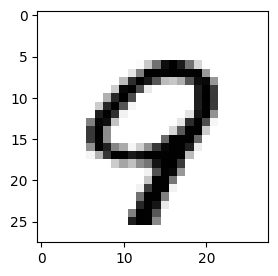

In [4]:
idx = 9900
print ( y_valid[ idx ] )
print ( X_valid[ idx ] )

fig = plt.figure( figsize=(3,3) )
# plt.imshow( X_valid_raw[ idx ].reshape( 28, 28 ), cmap='binary' )
plt.imshow( X_valid[ idx ].reshape( 28, 28 ), cmap='binary' )

In [5]:
# from keras.utils import np_utils
# y_train_onehot = np_utils.to_categorical( y_train , 10)
y_train_onehot = keras.utils.to_categorical( y_train , 10)
print ( y_train_onehot )
# y_test_onehot = np_utils.to_categorical( y_test , 10)
y_test_onehot = keras.utils.to_categorical( y_test , 10)
print ( y_test_onehot )

[[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
[[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]


In [6]:
class VAEwithConstraint(tf.keras.Model):

    def __init__(self, latent_dim, inter_dim):
        super(VAEwithConstraint, self).__init__()

        self.latent_dim = latent_dim
        self.inter_dim = inter_dim
        self.shape_ = (28, 28, 1)

        img = tf.keras.layers.Input( self.shape_ )

        x = tf.keras.layers.Conv2D(filters=32, kernel_size=3, strides=(2, 2), activation='relu')(img)
        x = tf.keras.layers.Conv2D(filters=64, kernel_size=3, strides=(2, 2), activation='relu')(x)
        x = tf.keras.layers.Flatten()(x)

        x = tf.keras.layers.Dense(self.inter_dim, activation='relu')(x)

        # x0 = tf.keras.layers.Dense(self.inter_dim//2, activation='relu')(x)
        # x1 = tf.keras.layers.Dense(self.inter_dim//2, activation='relu')(x)
        encoded = tf.keras.layers.Dense(self.latent_dim + self.latent_dim)(x)
        y = tf.keras.layers.Dense(10, activation='softmax')(x)
        self.encoder = tf.keras.Model(inputs=[img], outputs=[encoded, y])  # mu and log_var

        z = tf.keras.layers.Input((self.latent_dim,))
        input_y = tf.keras.layers.Input(shape=(10,))
        # z0 = tf.keras.layers.Dense(self.inter_dim//2)(z)
        # y0 = tf.keras.layers.Dense(self.inter_dim//2)(input_y)
        # merged_input = tf.keras.layers.Concatenate()([z0, y0])
        merged_input = tf.keras.layers.Concatenate()([z, input_y])

        x = tf.keras.layers.Dense(self.inter_dim)(merged_input)
        x = tf.keras.layers.Dense(7 * 7 * 32, activation='relu')(x)
        x = tf.keras.layers.Reshape(target_shape=(7, 7, 32))(x)
        x = tf.keras.layers.Conv2DTranspose(filters=64,
                                            kernel_size=3,
                                            strides=2,
                                            padding='same',
                                            activation='relu')(x)
        x = tf.keras.layers.Conv2DTranspose(filters=32,
                                            kernel_size=3,
                                            strides=2,
                                            padding='same',
                                            activation='relu')(x)
        x = tf.keras.layers.Conv2DTranspose(filters=1,
                                            kernel_size=3,
                                            strides=1,
                                            padding='same')(x)

        self.decoder = tf.keras.Model(inputs=[z, input_y], outputs=[x])

    # Sample z ~ Q(z|X,y)
    @tf.function
    def sample(self, eps, y):
        return self.decode(eps, y, apply_sigmoid=True)

    @tf.function
    def encode(self, x):
        encoded_, y_ = self.encoder([x])
        mean, logvar = tf.split(encoded_, num_or_size_splits=2, axis=1)
        return mean, logvar, y_

    @tf.function
    def reparameterize(self, mean, logvar):
        eps = tf.random.normal(shape=mean.shape)
        return eps * tf.exp(logvar * .5) + mean

    @tf.function
    def decode(self, z, y, apply_sigmoid=False):
        logits = self.decoder([z, y])
        if apply_sigmoid:
            probs = tf.sigmoid(logits)
            return probs
        return logits

In [ ]:
# help(tf.keras.layers.Dense)

In [21]:
from keras import ops as K

# def log_normal_pdf(sample, mean, logvar, raxis=1):
#     log2pi = tf.math.log(2. * np.pi)
#     return tf.reduce_sum(
#       -.5 * ((sample - mean) ** 2. * tf.exp(-logvar) + logvar + log2pi),
#       axis=raxis)

def compute_loss(model, x, y):

    mean, logvar, y_ = model.encode(x)
    z = model.reparameterize(mean, logvar)
    x_logit = model.decode(z,y_)

    # cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
    # logpx_z = -tf.reduce_sum(cross_ent, axis=[1, 2, 3])
    # logpz = log_normal_pdf(z, 0., 0.)
    # logqz_x = log_normal_pdf(z, mean, logvar)
    # loss_ = -tf.reduce_mean(logpx_z + logpz - logqz_x)

    cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
    cross_ent = tf.reduce_sum(cross_ent, axis=[1, 2, 3])
    kl_loss = -0.5 * K.sum( 1 + logvar - K.square(mean) - K.exp(logvar) , axis=-1 )
    loss_ = tf.reduce_mean( cross_ent + kl_loss + keras.losses.CategoricalCrossentropy(reduction=tf.keras.losses.Reduction.SUM)(y,y_) )

    return loss_

train_loss = tf.keras.metrics.Mean('train_loss', dtype=tf.float32)
test_loss = tf.keras.metrics.Mean('test_loss', dtype=tf.float32)

@tf.function
def train_step(model, x, y, optimizer):
    with tf.GradientTape() as tape:
        loss = compute_loss(model, x, y)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    train_loss(loss)

@tf.function
def test_step(model, x_test, y_test):
    test_loss(compute_loss(model, x_test, y_test))

# def generate_and_save_images(model, epoch, test_sample_x, test_sample_y):
#     mean, logvar = model.encode(test_sample_x, test_sample_y)
#     z = model.reparameterize(mean, logvar)
#     predictions = model.sample(z, test_sample_y)
#     fig = plt.figure(figsize=(4, 4))
#     for i in range(predictions.shape[0]):
#         plt.subplot(4, 4, i + 1)
#         plt.imshow(predictions[i, :, :, 0], cmap='gray')
#         plt.axis('off')
#         plt.savefig('images/image_at_epoch_{:04d}.png'.format(epoch))
#     # plt.show()

# batch_size = 512
# latent_dim = 8
# inter_dim = 128
# n_epochs = 30
# learning_rate = 1e-4
batch_size = 32
latent_dim = 4
inter_dim = 128
n_epochs = 25
learning_rate = 1e-4

import datetime
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
train_log_dir = 'logs/gradient_tape/' + current_time + '/train'
test_log_dir = 'logs/gradient_tape/' + current_time + '/test'
train_summary_writer = tf.summary.create_file_writer(train_log_dir)
test_summary_writer = tf.summary.create_file_writer(test_log_dir)

train_dataset = ( tf.data.Dataset.from_tensor_slices( ( X_train, y_train_onehot ) )
                    .shuffle( X_train.shape[0] ).batch( batch_size ) )
test_dataset = ( tf.data.Dataset.from_tensor_slices( ( X_test, y_test_onehot ) )
                    .shuffle( X_test.shape[0] ).batch( batch_size ) )

optimizer = tf.keras.optimizers.Adam( learning_rate )

model = VAEwithConstraint( latent_dim, inter_dim )
model.encoder.summary()
model.decoder.summary()

for epoch in range( n_epochs ):
    for train in train_dataset:
        train_step(model, train[0], train[1], optimizer)
        with train_summary_writer.as_default():
            tf.summary.scalar('loss', train_loss.result(), step=epoch)

    for test in test_dataset:
        test_step(model, test[0], test[1])
        with test_summary_writer.as_default():
            tf.summary.scalar('loss', test_loss.result(), step=epoch)

    template = 'Epoch {}, Loss: {}, Test Loss: {}'
    print(template.format(epoch + 1, train_loss.result(), test_loss.result()))
    # Reset metrics every epoch
    train_loss.reset_state()
    test_loss.reset_state()
    # generate_and_save_images(model, epoch, test_sample_x, test_sample_y)

# model.save_weights('saved_model/my_checkpoint')

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 13, 13,    │        320 │ input_layer_12[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 6, 6, 64)  │     18,496 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 2304)      │          0 │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 128)       │    295,040 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 8)         │      1,032 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 10)        │      1,290 │ dense_20[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 316,178 (1.21 MB)

 Trainable params: 316,178 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_14      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 14)        │          0 │ input_layer_13[0… │
│ (Concatenate)       │                   │            │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 128)       │      1,920 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 1568)      │    202,272 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 7, 7, 32)  │          0 │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_12 │ (None, 14, 14,    │     18,496 │ reshape_4[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_13 │ (None, 28, 28,    │     18,464 │ conv2d_transpose… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_14 │ (None, 28, 28, 1) │        289 │ conv2d_transpose… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 241,441 (943.13 KB)

 Trainable params: 241,441 (943.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1, Loss: 199.49838256835938, Test Loss: 145.1241455078125
Epoch 2, Loss: 140.32080078125, Test Loss: 134.63613891601562
Epoch 3, Loss: 133.45492553710938, Test Loss: 130.2805633544922
Epoch 4, Loss: 129.66934204101562, Test Loss: 127.55162048339844
Epoch 5, Loss: 127.2279281616211, Test Loss: 125.36552429199219
Epoch 6, Loss: 125.29933166503906, Test Loss: 123.55723571777344
Epoch 7, Loss: 123.84253692626953, Test Loss: 122.78179931640625
Epoch 8, Loss: 122.63521575927734, Test Loss: 121.83002471923828
Epoch 9, Loss: 121.58370971679688, Test Loss: 120.56893920898438
Epoch 10, Loss: 120.64390563964844, Test Loss: 119.75070190429688
Epoch 11, Loss: 119.75624084472656, Test Loss: 119.04289245605469
Epoch 12, Loss: 118.95024871826172, Test Loss: 118.28068542480469
Epoch 13, Loss: 118.1633071899414, Test Loss: 117.71212005615234
Epoch 14, Loss: 117.42427062988281, Test Loss: 117.13883972167969
Epoch 15, Loss: 116.70142364501953, Test Loss: 116.53085327148438
Epoch 16, Loss: 116.050720

In [15]:
#for layer in model.encoder.layers:
#   print ( layer.output_shape )

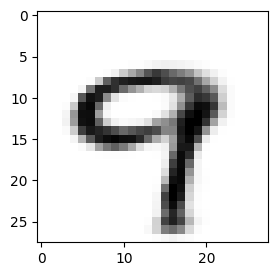

In [22]:
# np.random.seed(100)

label_ = 9
# img_ = model.sample( np.random.randn( 1, latent_dim ).astype( np.float32 ), np_utils.to_categorical( label_, 10 ).reshape( 1, 10 ) )
z_ = np.random.randn( 1, latent_dim ).astype( np.float32 )
y_=keras.utils.to_categorical( label_, 10 ).reshape( 1, 10 )
img_ = model.sample( z_, y_ )

fig = plt.figure( figsize=(3,3) )
plt.imshow( ( img_[ 0 ].numpy().reshape(28,28) * 255. ), cmap='binary' )


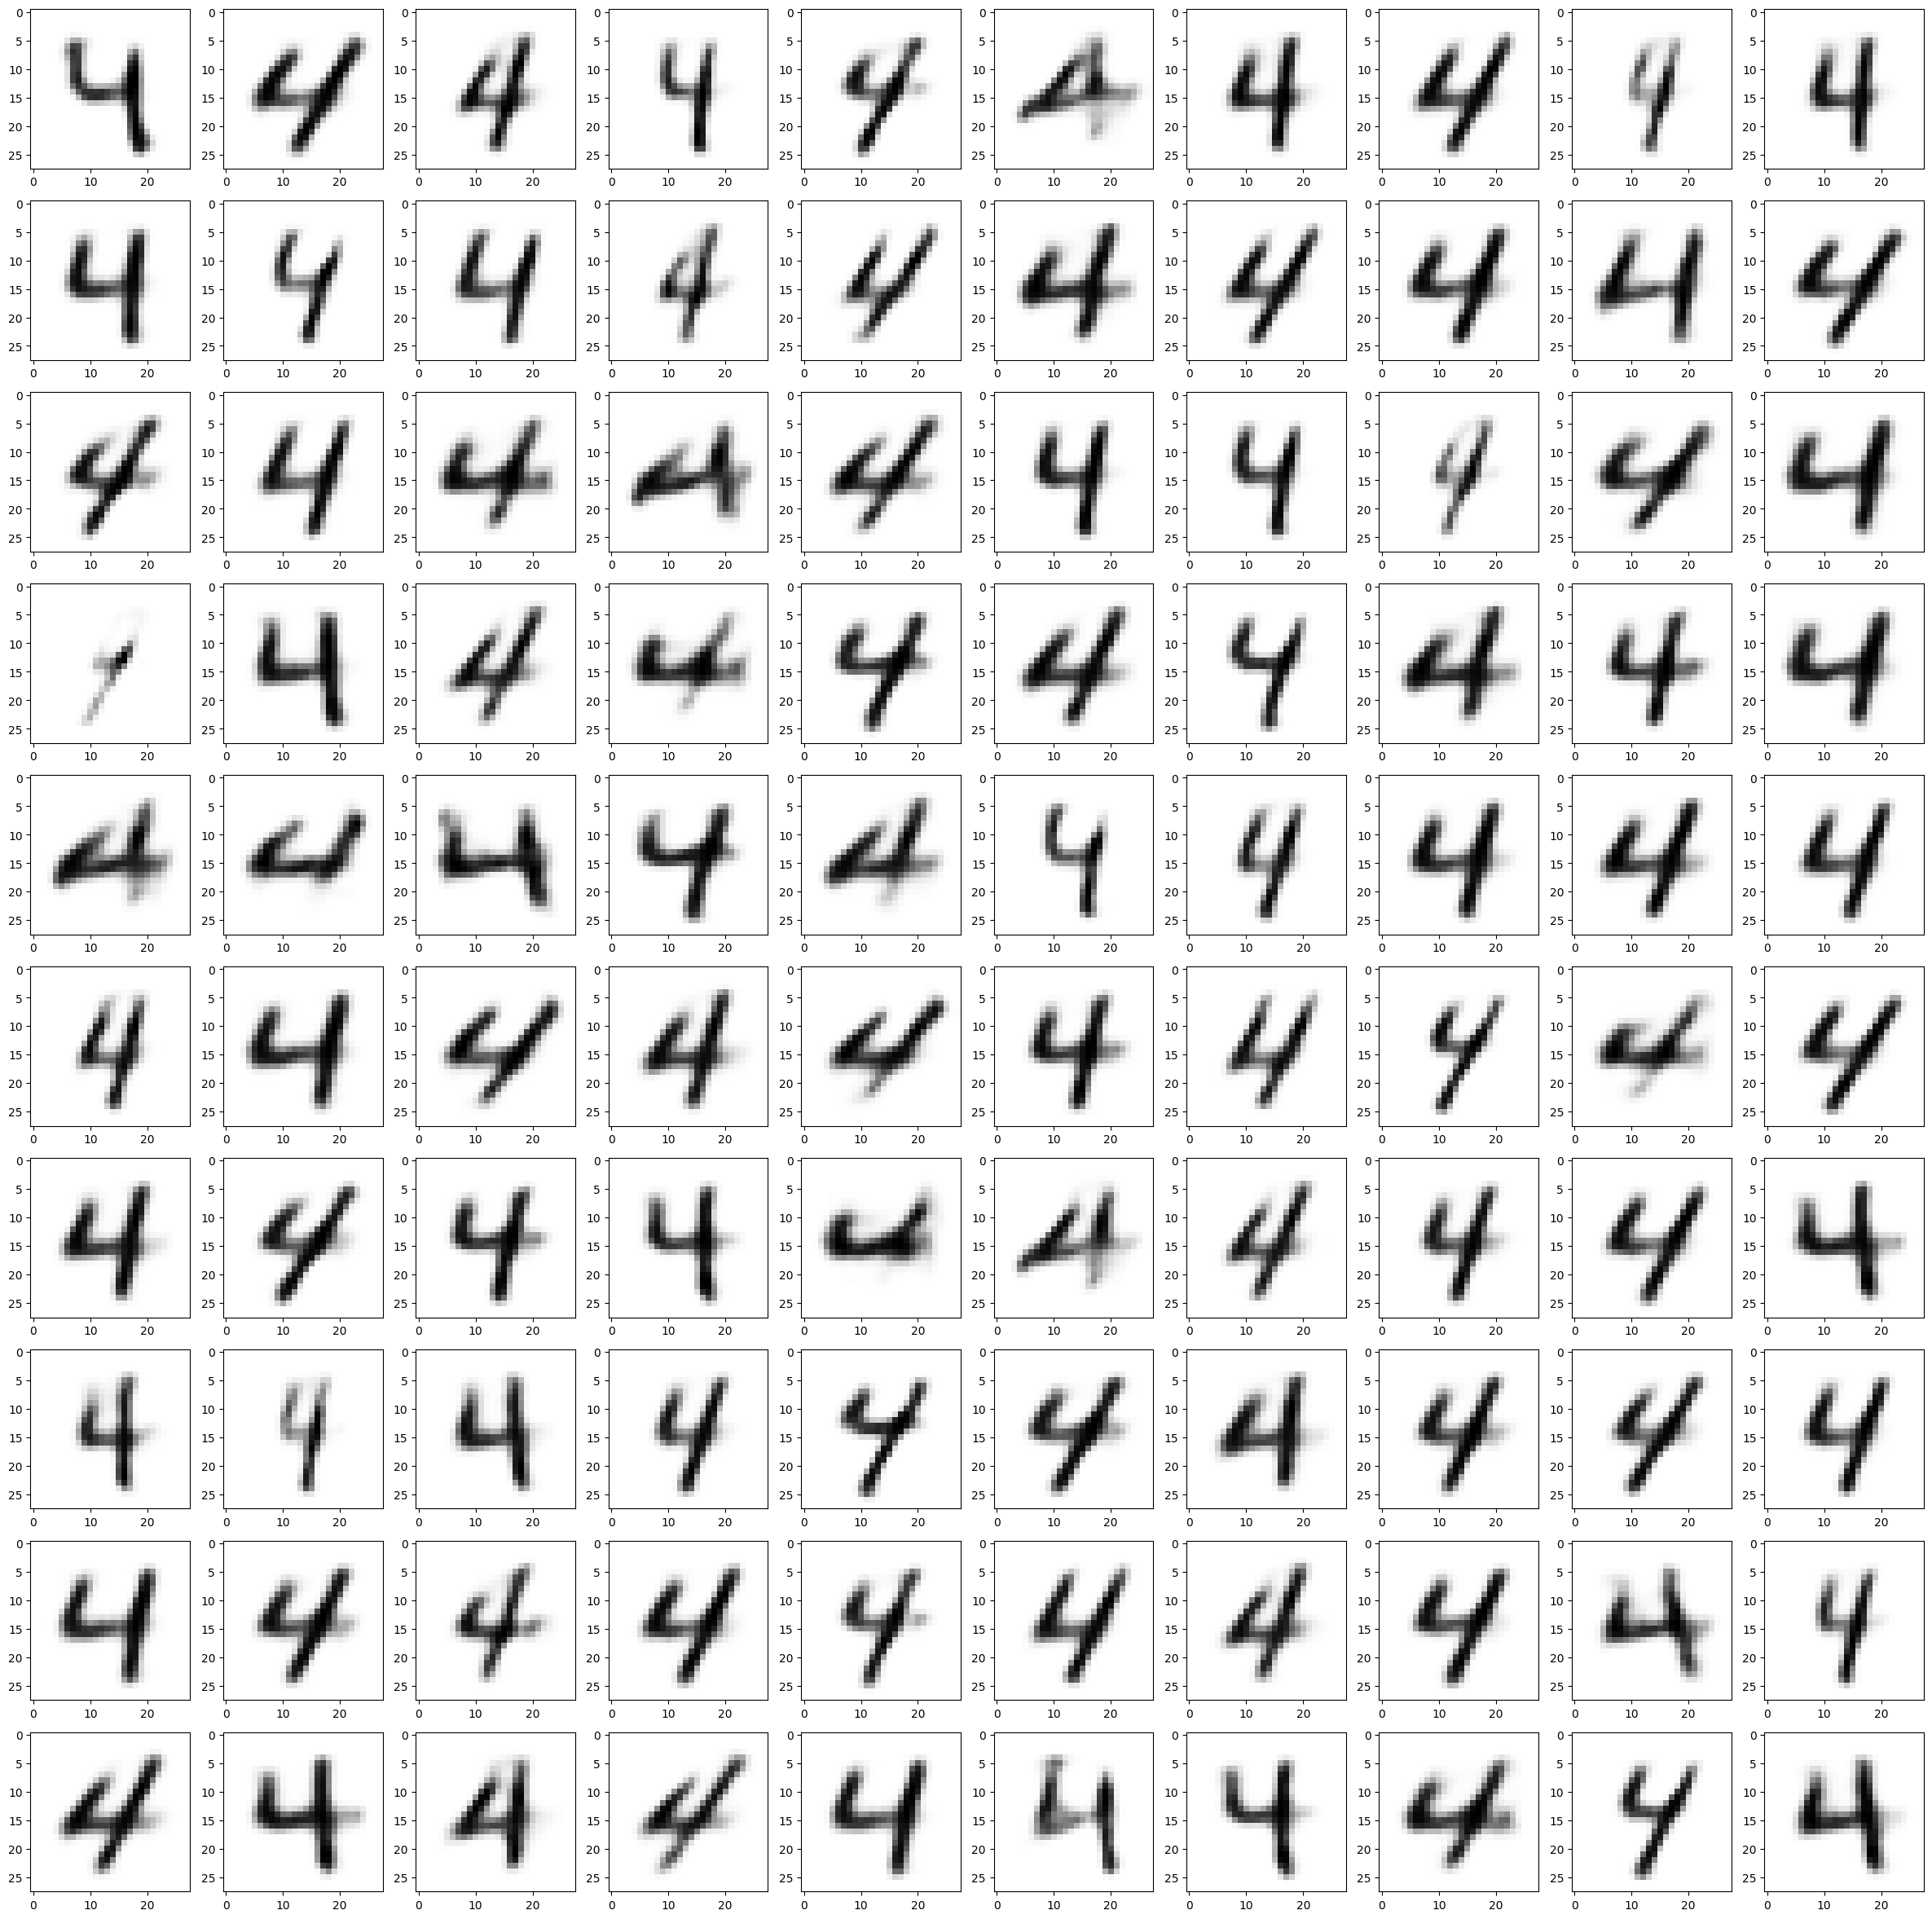

In [23]:
def plot_digits( label, n ):
    label__ = label
    size_ = 3
    fig_, axes_ = plt.subplots( n, n, figsize=( n * size_ , n * size_ ) )
    for idx_row__ in range( n ):
        for idx_col__ in range( n ):
            ax_ = axes_[ idx_row__, idx_col__ ]
            img_ = model.sample( np.random.randn( 1, latent_dim ).astype( np.float32 ), keras.utils.to_categorical( label__, 10 ).reshape( 1, 10 ) )
            ax_.imshow( ( img_[ 0 ].numpy().reshape(28,28) * 255. ), cmap='binary' )

label = 4
plot_digits( label, 10 )

In [ ]:
y_test_pred = np.argmax( model.encode( X_test )[-1], axis=1 )
print ( y_test_pred )
accuracy = np.sum( y_test_pred == y_test ) / y_test.size
print ( "Accuracy = {}".format( accuracy ) )

[0 0 0 ... 9 9 9]
Accuracy = 0.9825
